In [16]:
from getdist import loadMCSamples
import getdist.plots as plots
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

### The Core Analysis Class

In [17]:
class CobayaAnalyzer:
    def __init__(self, chain_dicts, burn_in=0.3):
        """
        Initialize the analyzer.

        arg:
            chain_dicst: Dictionayr of {'chains_name': ['chains_path', 'dataset_label']}
            burin_in: Fraction of the chain to discard (default: 30%)
        """
        self.chains = chain_dicts.copy()
        self.burn_in = burn_in

        self._load_chains()
        self._setup_publication_style()

    def _load_chains(self):
        """
        Loads all specified chains using GetDist.
        """
        print(f"Loading chains")
        for experiment, [chain_path, _, _] in self.chains.items():
            try:
                self.chains[experiment][0] = loadMCSamples(chain_path, settings={'ignore_rows': self.burn_in,
                                                             'smooth_scale_1D': -1, 
                                                             'smooth_scale_2D': -1})

            except Exception as e:
                print(f" -> Error loading {experiment}: {e}")

    def _setup_publication_style(self):
        """
        Applies global matplotlib setting for publication-quality plots
        """
        plt.rcParams['text.usetex'] = False 
        plt.rcParams['mathtext.fontset'] = 'cm' 
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']

    def plot_triangle(self, params, colors=None, fontsize=None, combined=True, save_as=None):
        """
        Generates a 1D/2D triangle plot.

        arg:
            params: List of parameter string.
            colors: Custom color list for the contours.
            fontsize: a list of [axes, lab, legend] sizes
            combined: 
        """
        plot_settings = plots.GetDistPlotSettings()

        # Adjust Font Sizes
        plot_settings.axes_fontsize = fontsize[0]     # Tick numbers
        plot_settings.lab_fontsize = fontsize[1]      # Axis labels (x, y)
        plot_settings.legend_fontsize = fontsize[2]   # Legend text

        # Visual Tweaks for Publications
        plot_settings.figure_legend_frame = False  # Removes the box around the legend
        plot_settings.alpha_filled_add = 0.85      # Adjust transparency of filled contours

        g = plots.get_subplot_plotter(settings=plot_settings)

        if combined:
            sample_list = []
            dataset_list = []
            for list in self.chains.values():
                sample_list.append(list[0])
                dataset_list.append(list[1])
            g.triangle_plot(roots=sample_list, 
                            params=params, 
                            legend_labels=dataset_list, 
                            filled=True, 
                            contour_colors=colors,
                            contour_ls='-',
                            contour_lws=1.5)
            if save_as:
                g.export(f'figure/chains_combined_{save_as}.pdf')
            
        else:
            for experiment, [sample, dataset, _] in self.chains.items():
                available_params = [param for param in params if param in sample.getParamNames().list()]
                g.triangle_plot(roots=[sample], 
                                params=available_params, 
                                legend_labels=[dataset], 
                                filled=True, 
                                contour_colors=colors,
                                contour_ls='-',
                                contour_lws=1.5)
                if save_as:
                    g.export(f'figure/chains_{experiment}_{save_as}.pdf')

    def _get_available_latex_lables(self):
        """
        Retrieves the available LaTeX labels for the parameters in the loaded chains.
        """
        available_latex_labels = {}
        for _, [sample, _, _] in self.chains.items():
            params_names = sample.getParamNames().list()

            for param in params_names:
                if param not in available_latex_labels.keys():
                    available_latex_labels[param] = sample.parLabel(param)
        return available_latex_labels
    
    def generate_summary_table(self, params, limit=1):
        """
        Generates a summary table of the mean and 1-sigma errors for the specified parameters.

        arg:
            params: List of parameter strings.
            limit: Number of significant figures to round to (default: 1).
        """
        if params is None:
            print("No parameters specified for the summary table.")
            return
        else:
            available_params = self._get_available_latex_lables()
            latex_labels = [available_params[param] if param in available_params.keys() else print(f"Parameter {param} not found in available LaTeX labels.") for param in params]
        table_latex = "\\begin{table*}\n"
        table_latex += "\\centering\n"
        table_latex += "\\resizebox{\linewidth}{!}{\n" 
        table_latex += "\\begin{tabular}{l"+ "c"*len(params) +"}\n"
        table_latex += "\\toprule\n"

        # Title
        table_latex += "Model/Dataset "
        for label in latex_labels:
            table_latex += f"& {label} "
        table_latex += "\\\\\n"
        table_latex += "\\midrule\n"

        # Data Result
        model_table = {}
        for _, [sample, dataset, model] in self.chains.items():
            if model not in model_table.keys():
                model_table[model] = model + " & "*len(params) + "\\\\ \n"

            # Report each line with the result from each dataset with the same model
            model_table[model] += dataset
            for param in params:
                try:
                    model_table[model] += " & " + "$" + sample.getInlineLatex(param, limit=limit).replace(">","=>").replace("<","=<").split("=", 1)[1]+ "$"
                except:
                    model_table[model] += " & --- "
            model_table[model] += " \\\\ \n"

        for table in model_table.values():
            table_latex += table
            table_latex += "\\hline\n"

        table_latex += "\\end{tabular}\n"
        table_latex += "}\n"
        table_latex += "\\caption{write the caption}\n"
        table_latex += "\\label{tab:cosmo_constraints}\n"
        table_latex += "\\end{table*}"    

        print(table_latex)

    def generate_best_fit_table(self, params):
        """
        Generates a summary table of the mean and 1-sigma errors for the specified parameters.

        arg:
            params: List of parameter strings.
            limit: Number of significant figures to round to (default: 1).
        """
        if params is None:
            print("No parameters specified for the summary table.")
            return
        else:
            available_params = self._get_available_latex_lables()
            latex_labels = [available_params[param] if param in available_params.keys() else print(f"Parameter {param} not found in available LaTeX labels.") for param in params]
        table_latex = "\\begin{table*}\n"
        table_latex += "\\centering\n"
        table_latex += "\\resizebox{\linewidth}{!}{\n" 
        table_latex += "\\begin{tabular}{l"+ "c"*len(params) +"}\n"
        table_latex += "\\toprule\n"

        # Title
        table_latex += "Model/Dataset "
        for label in latex_labels:
            table_latex += f"& {label} "
        table_latex += "\\\\\n"
        table_latex += "\\midrule\n"

        # Data Result
        model_table = {}
        for _, [sample, dataset, model] in self.chains.items():
            if model not in model_table.keys():
                model_table[model] = model + " & "*len(params) + "\\\\ \n"

            # Report each line with the result from each dataset with the same model
            model_table[model] += dataset
            best_fit_params = sample.getParamBestFitDict(best_sample=True)
            for param in params:
                try:
                    model_table[model] += " & " + "$" + f'{best_fit_params[param]:.3f}'+ "$"
                except:
                    model_table[model] += " & --- "
            model_table[model] += " \\\\ \n"

        for table in model_table.values():
            table_latex += table
            table_latex += "\\hline\n"

        table_latex += "\\end{tabular}\n"
        table_latex += "}\n"
        table_latex += "\\caption{write the caption}\n"
        table_latex += "\\label{tab:cosmo_constraints}\n"
        table_latex += "\\end{table*}"    

        print(table_latex)


### Setup Chain Dictionary

In [18]:
# Set Main Chain Dictionary
chains = {}
models = {}
chain_dir = Path(r'/home/theppawan/cosmo-research/quintom-project/chains')
chain_prefixes = [p.with_suffix('') for p in chain_dir.rglob('*.checkpoint')]

for prefix_path in chain_prefixes:
    chain_name = prefix_path.name
    model, dataset = chain_name.split("_", 1)

    # Set model label
    if 'lcdm' in model:
        models_label = r'\Lambda {\rm CDM}'
    else:
        models_label = model.capitalize()
    models[model] = models_label

    # Set dataset label
    if 'theta' in dataset:
        label = dataset.replace("theta", r"$\theta_*$")
    else:
        label = dataset
    chains[chain_name] = [str(prefix_path), rf"{label}", models_label]

# Sub-Dictionary
lcdm_chains = {key: chains[key] for key in chains.keys() if 'lcdm' in key}
quintom_chains = {key: chains[key] for key in chains.keys() if 'quintom' in key}

### $\Lambda {\rm CDM}$ Model

In [21]:
lcdm_analyzer = CobayaAnalyzer(chain_dicts=lcdm_chains, burn_in=0.3)

Loading chains


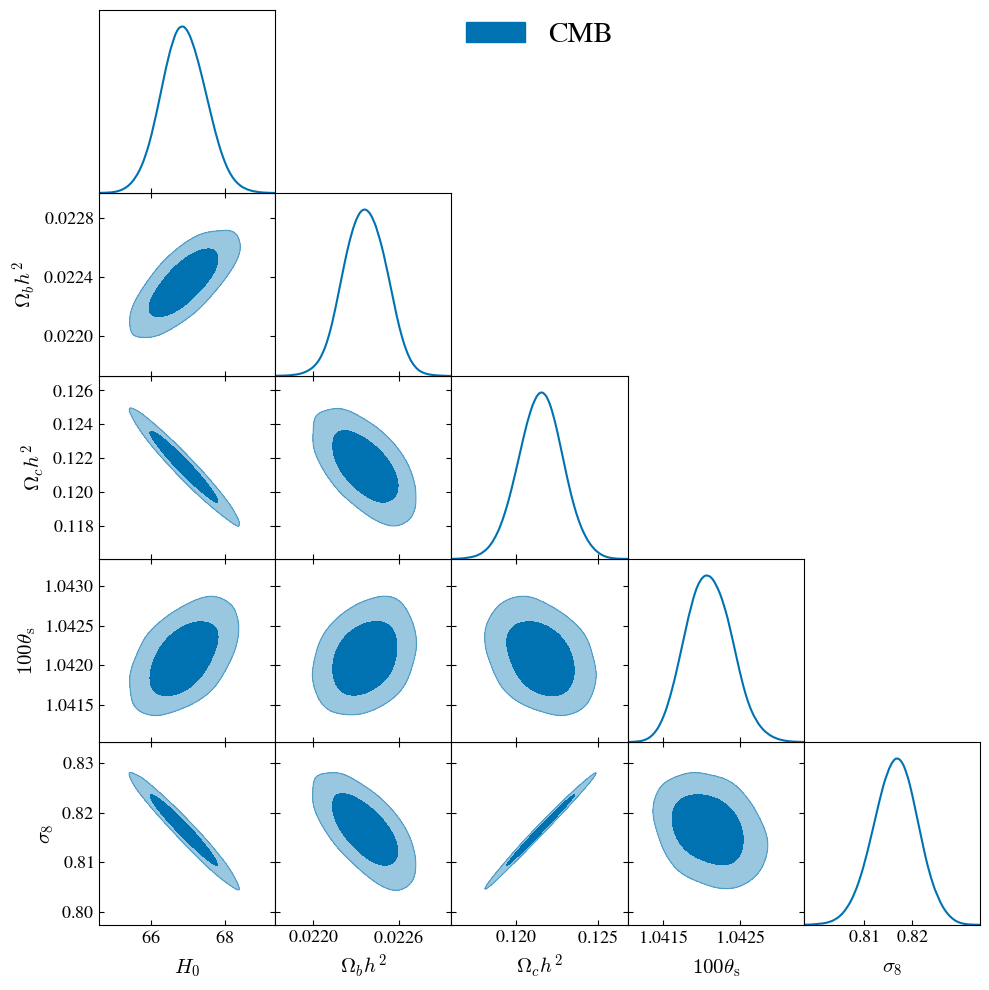

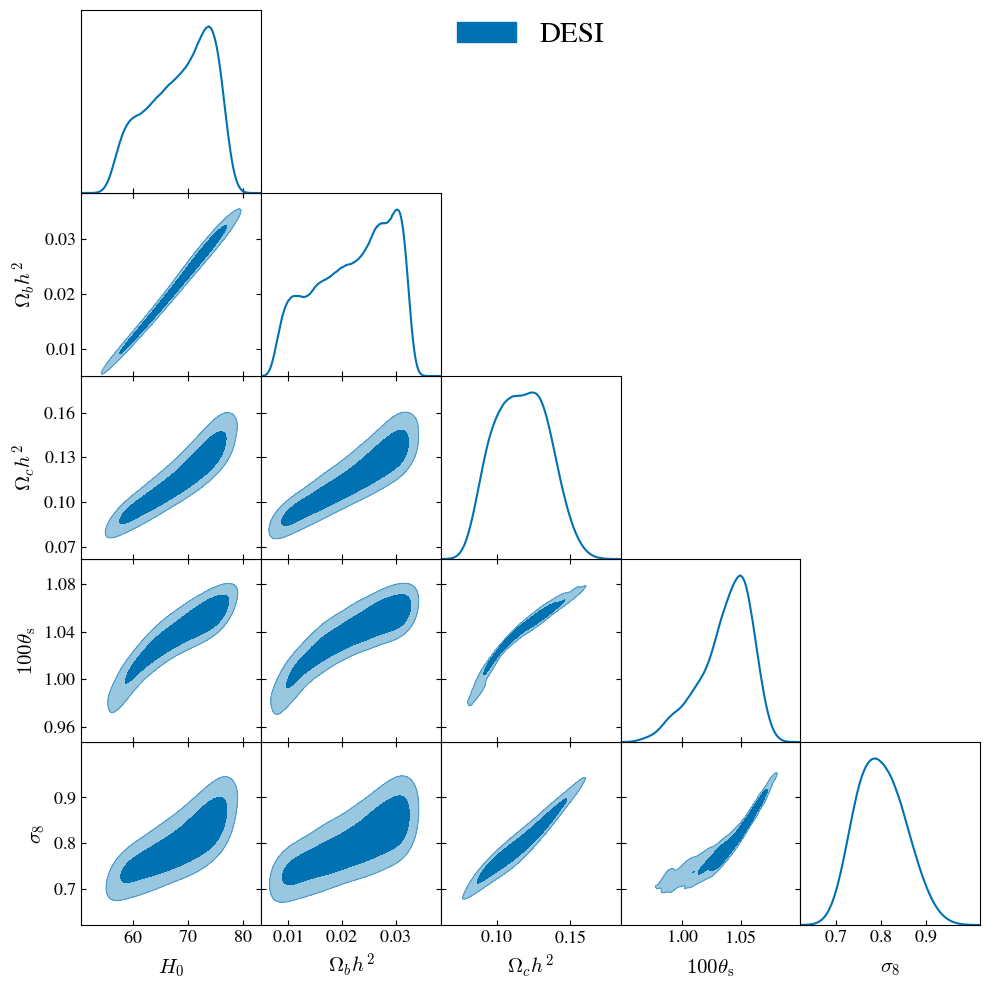

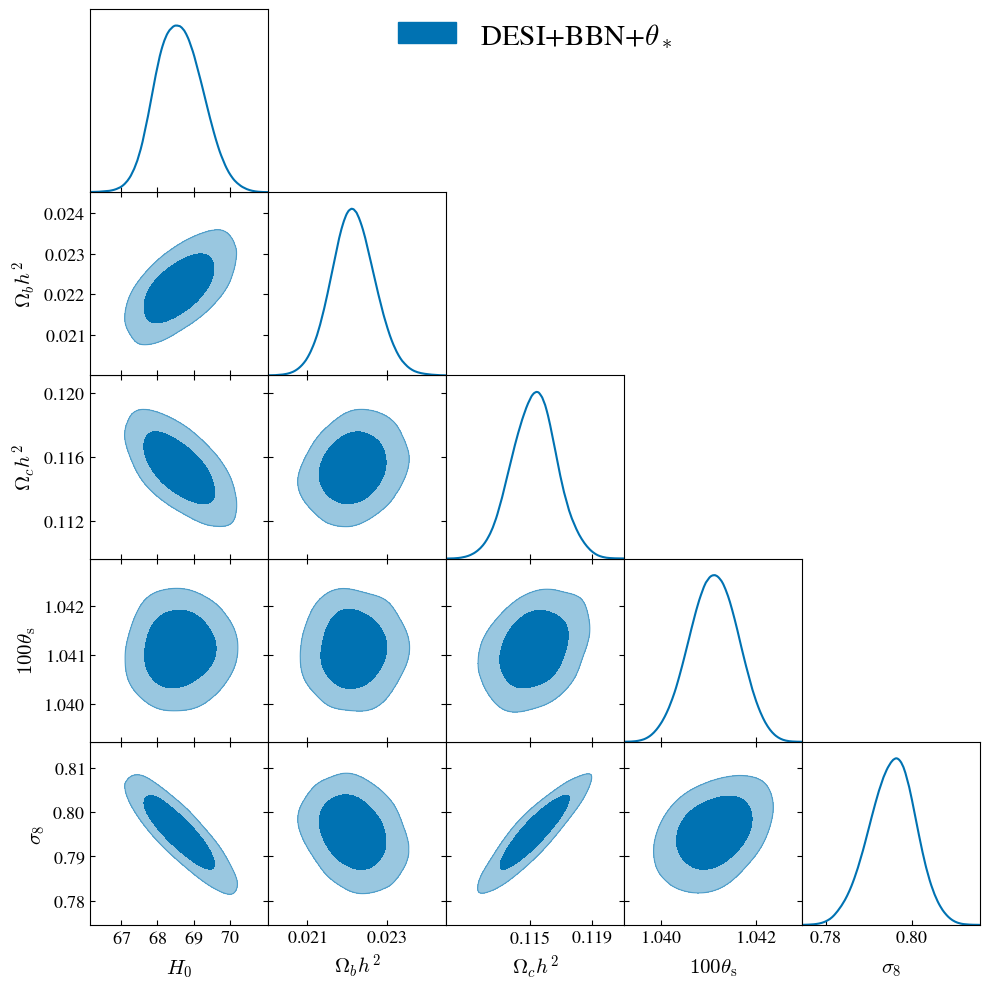

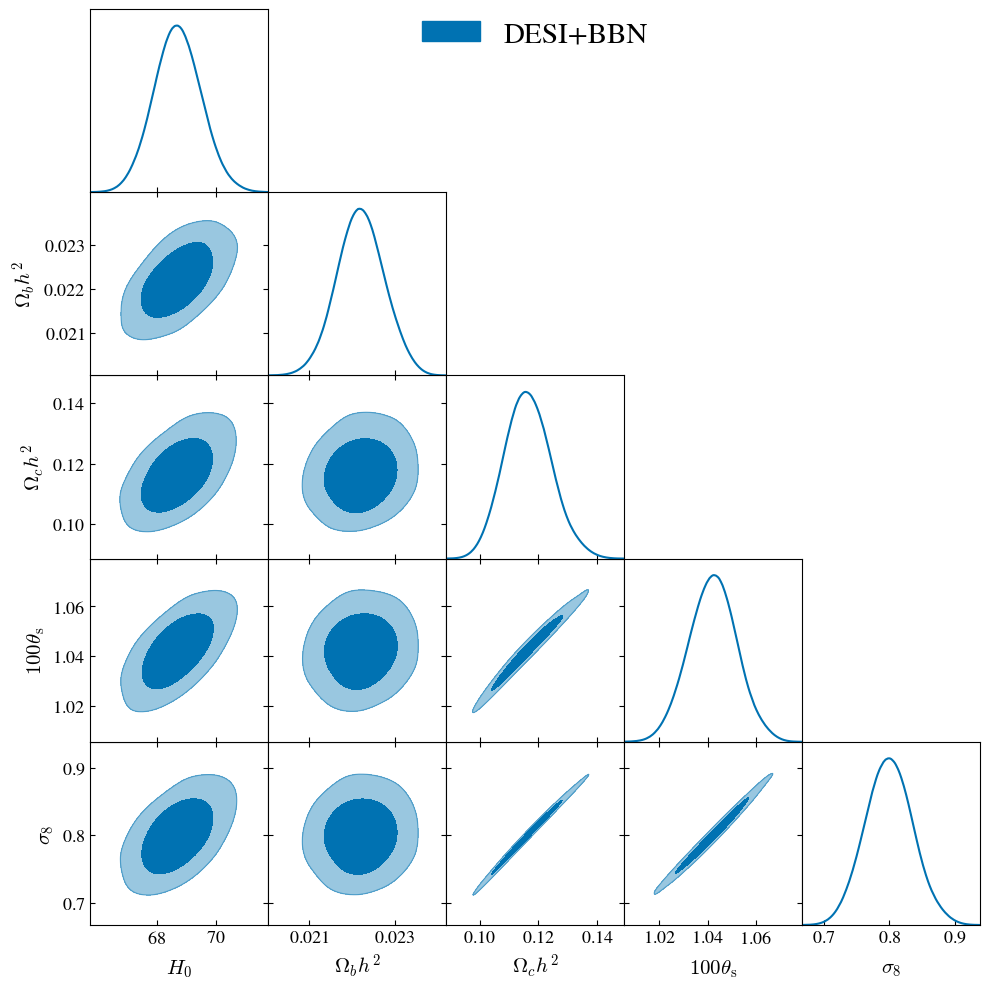

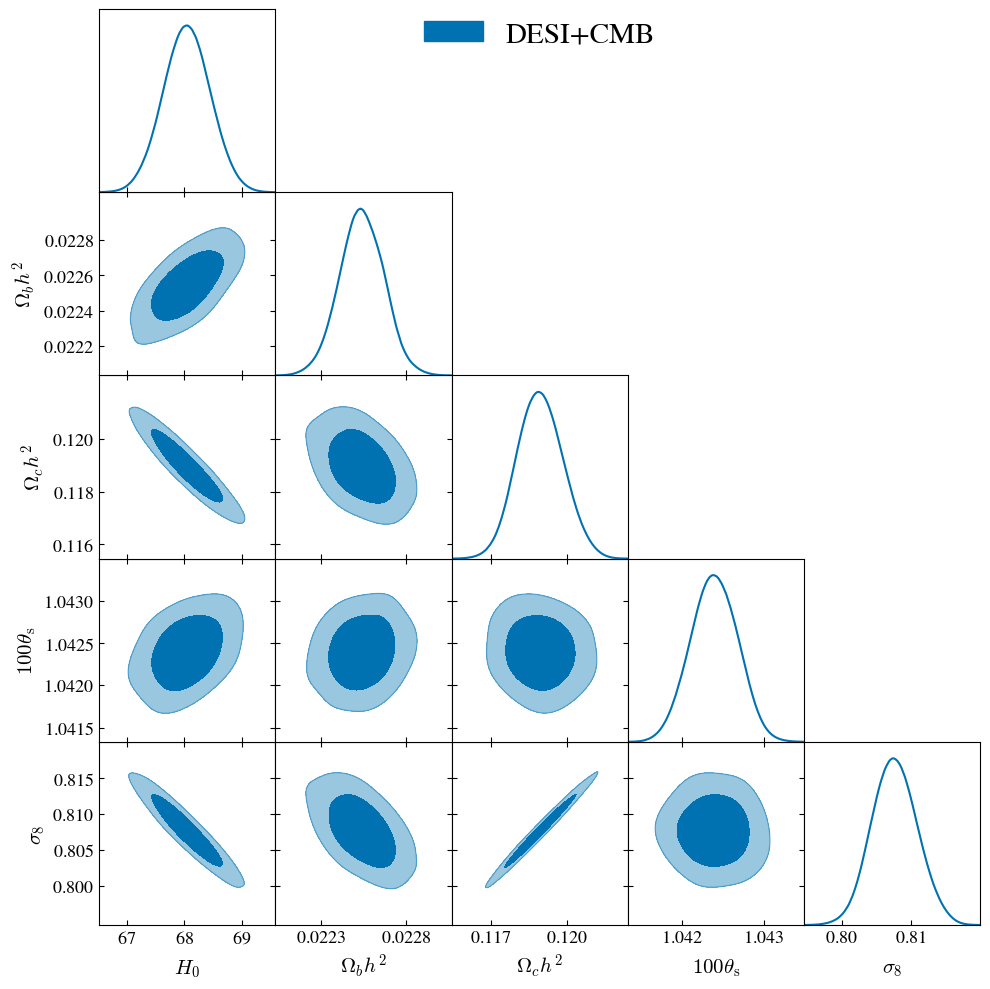

In [22]:
lcdm_analyzer.plot_triangle(params=['H0', 'omega_b', 'omega_cdm', 'theta_s_100', 'sigma8'], 
                       colors=["#0072B2"], 
                       fontsize=[16,18,24], 
                       combined=False, 
                       save_as='final')

### Quintom Model

In [28]:
quintom_analyzer = CobayaAnalyzer(chain_dicts=quintom_chains, burn_in=0.3)

Loading chains
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa/quintom_DESI+BBN+SNIa.1.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa/quintom_DESI+BBN+SNIa.2.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa/quintom_DESI+BBN+SNIa.3.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+BBN+SNIa/quintom_DESI+BBN+SNIa.4.txt
Removed 0.3 as burn in
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+SNIa/quintom_DESI+SNIa.1.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+SNIa/quintom_DESI+SNIa.2.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+SNIa/quintom_DESI+SNIa.3.txt
/home/theppawan/cosmo-research/quintom-project/chains/quintom/DESI+SNIa/quintom_DESI+SNIa.4.txt
Removed 0.3 as burn in


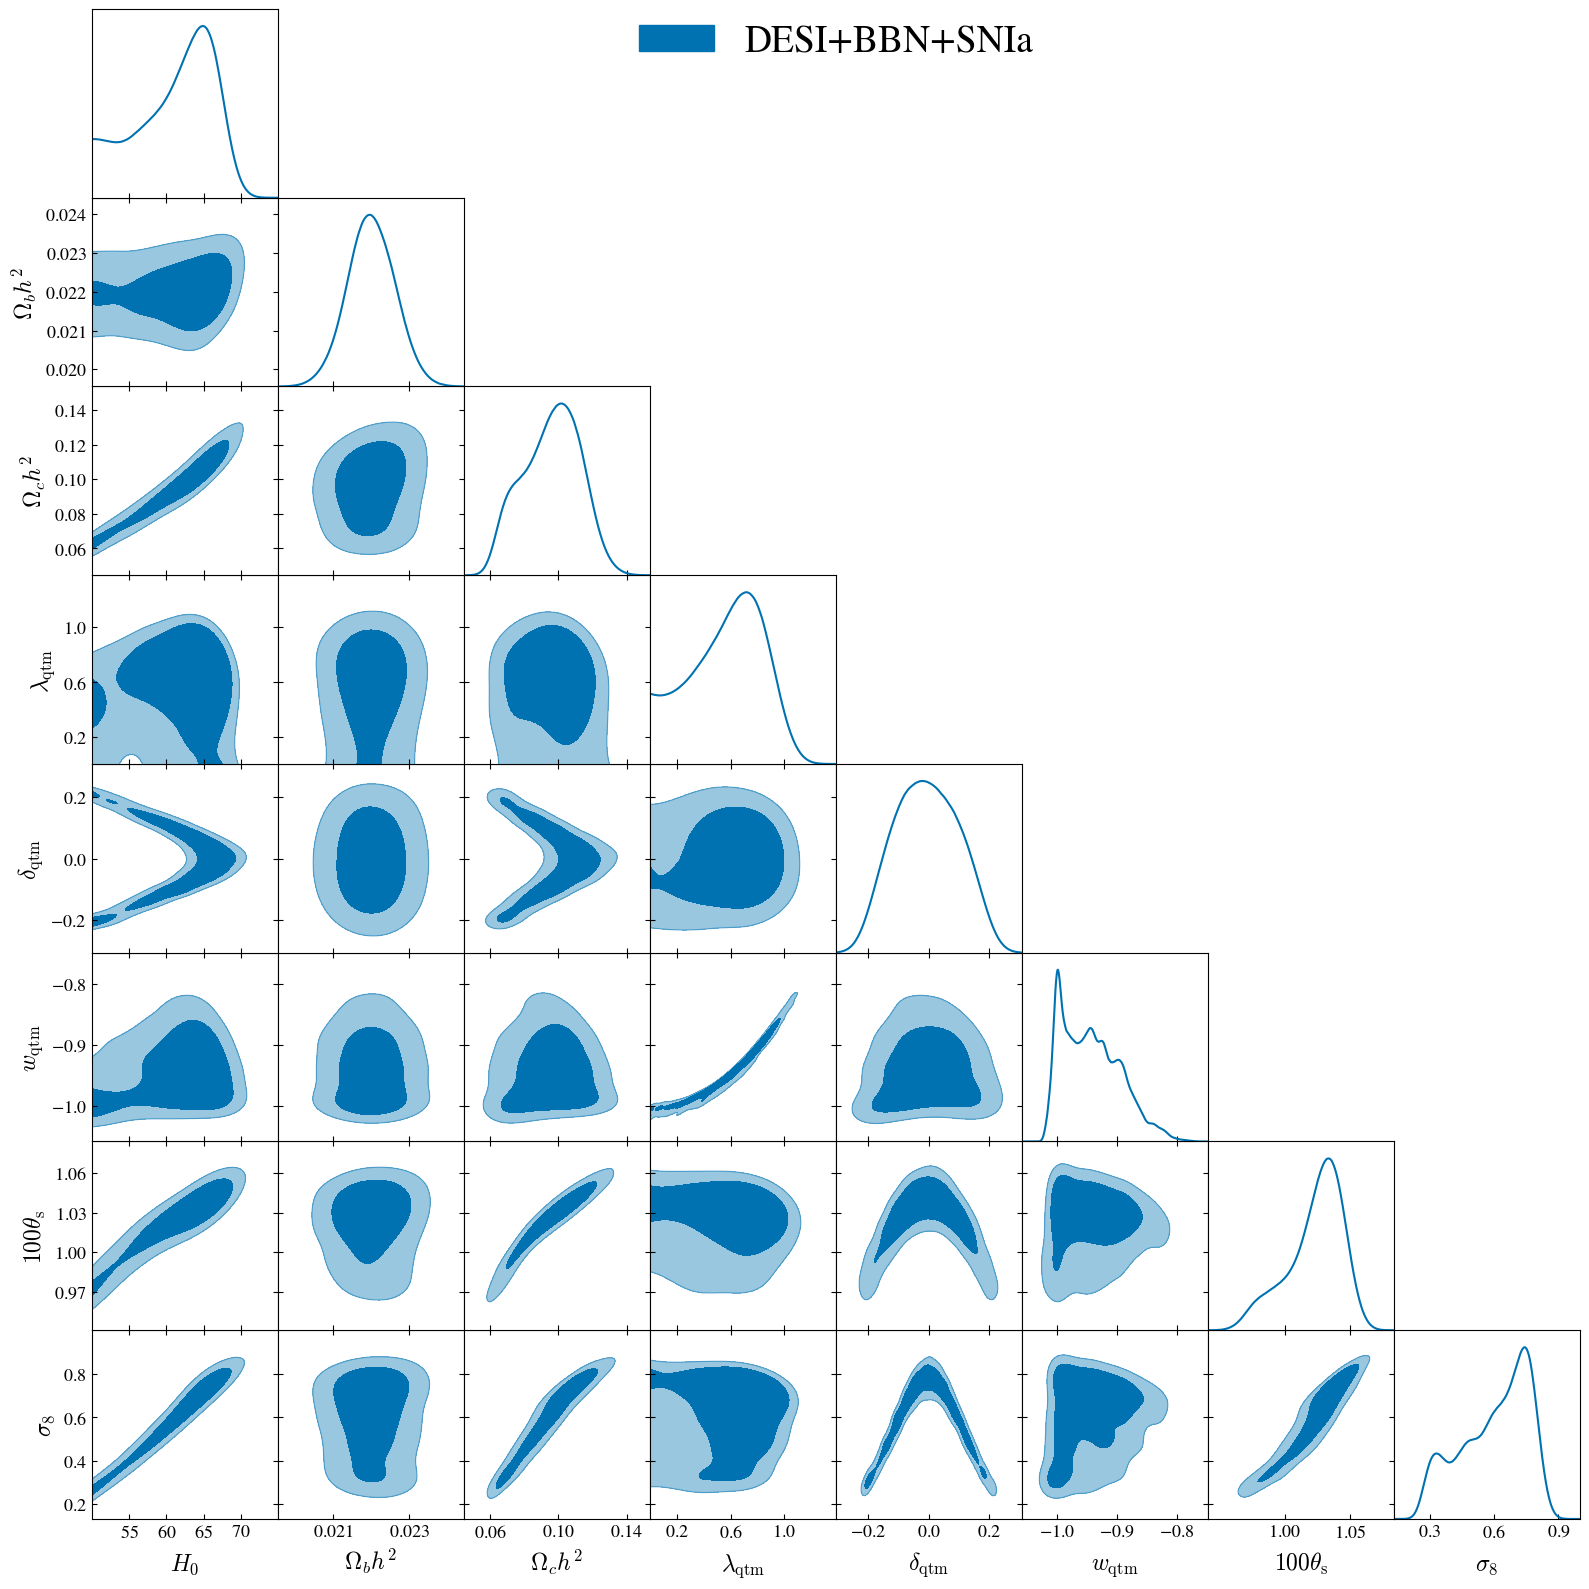

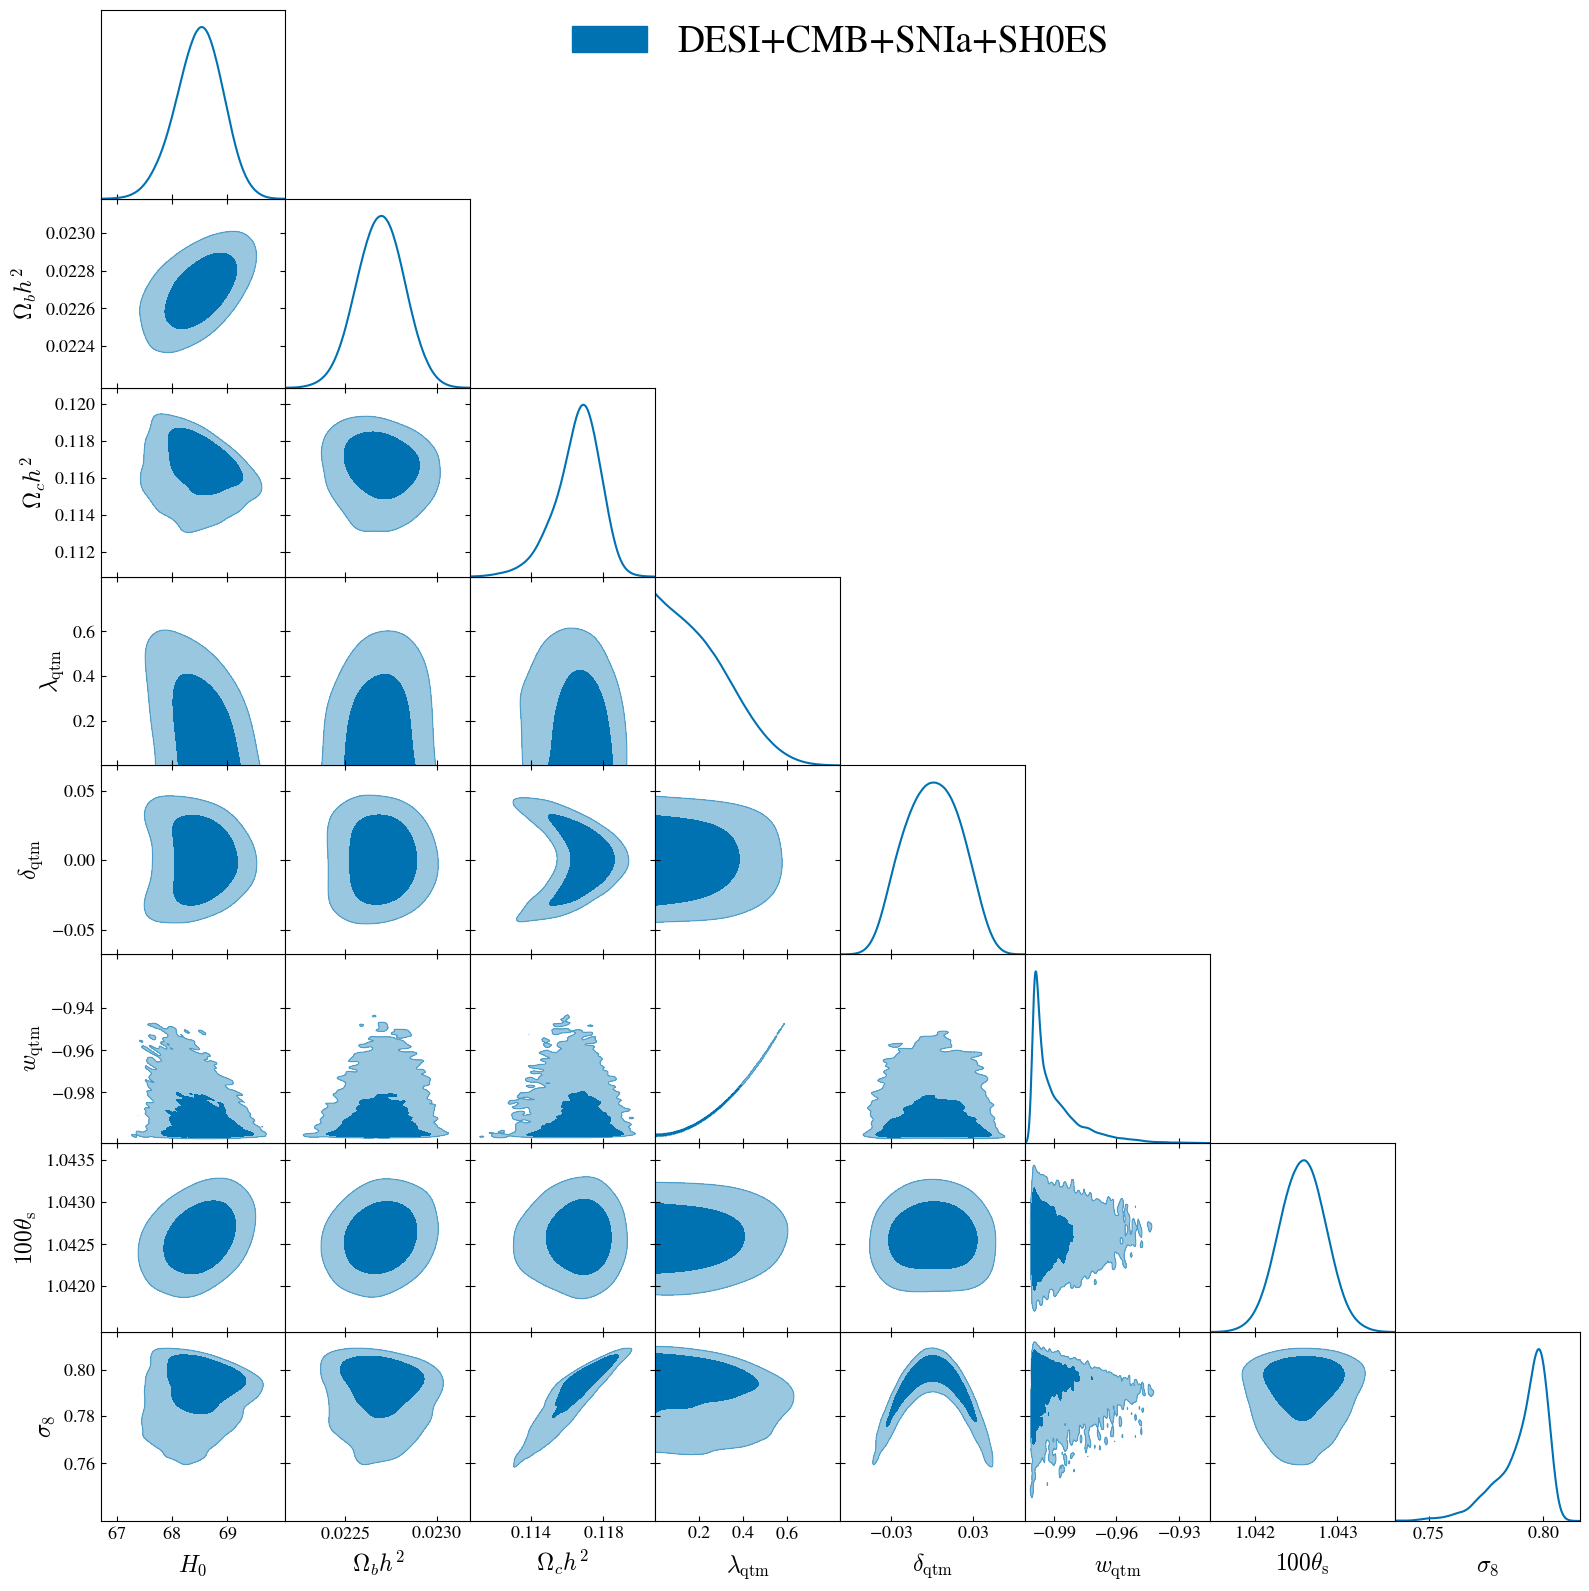

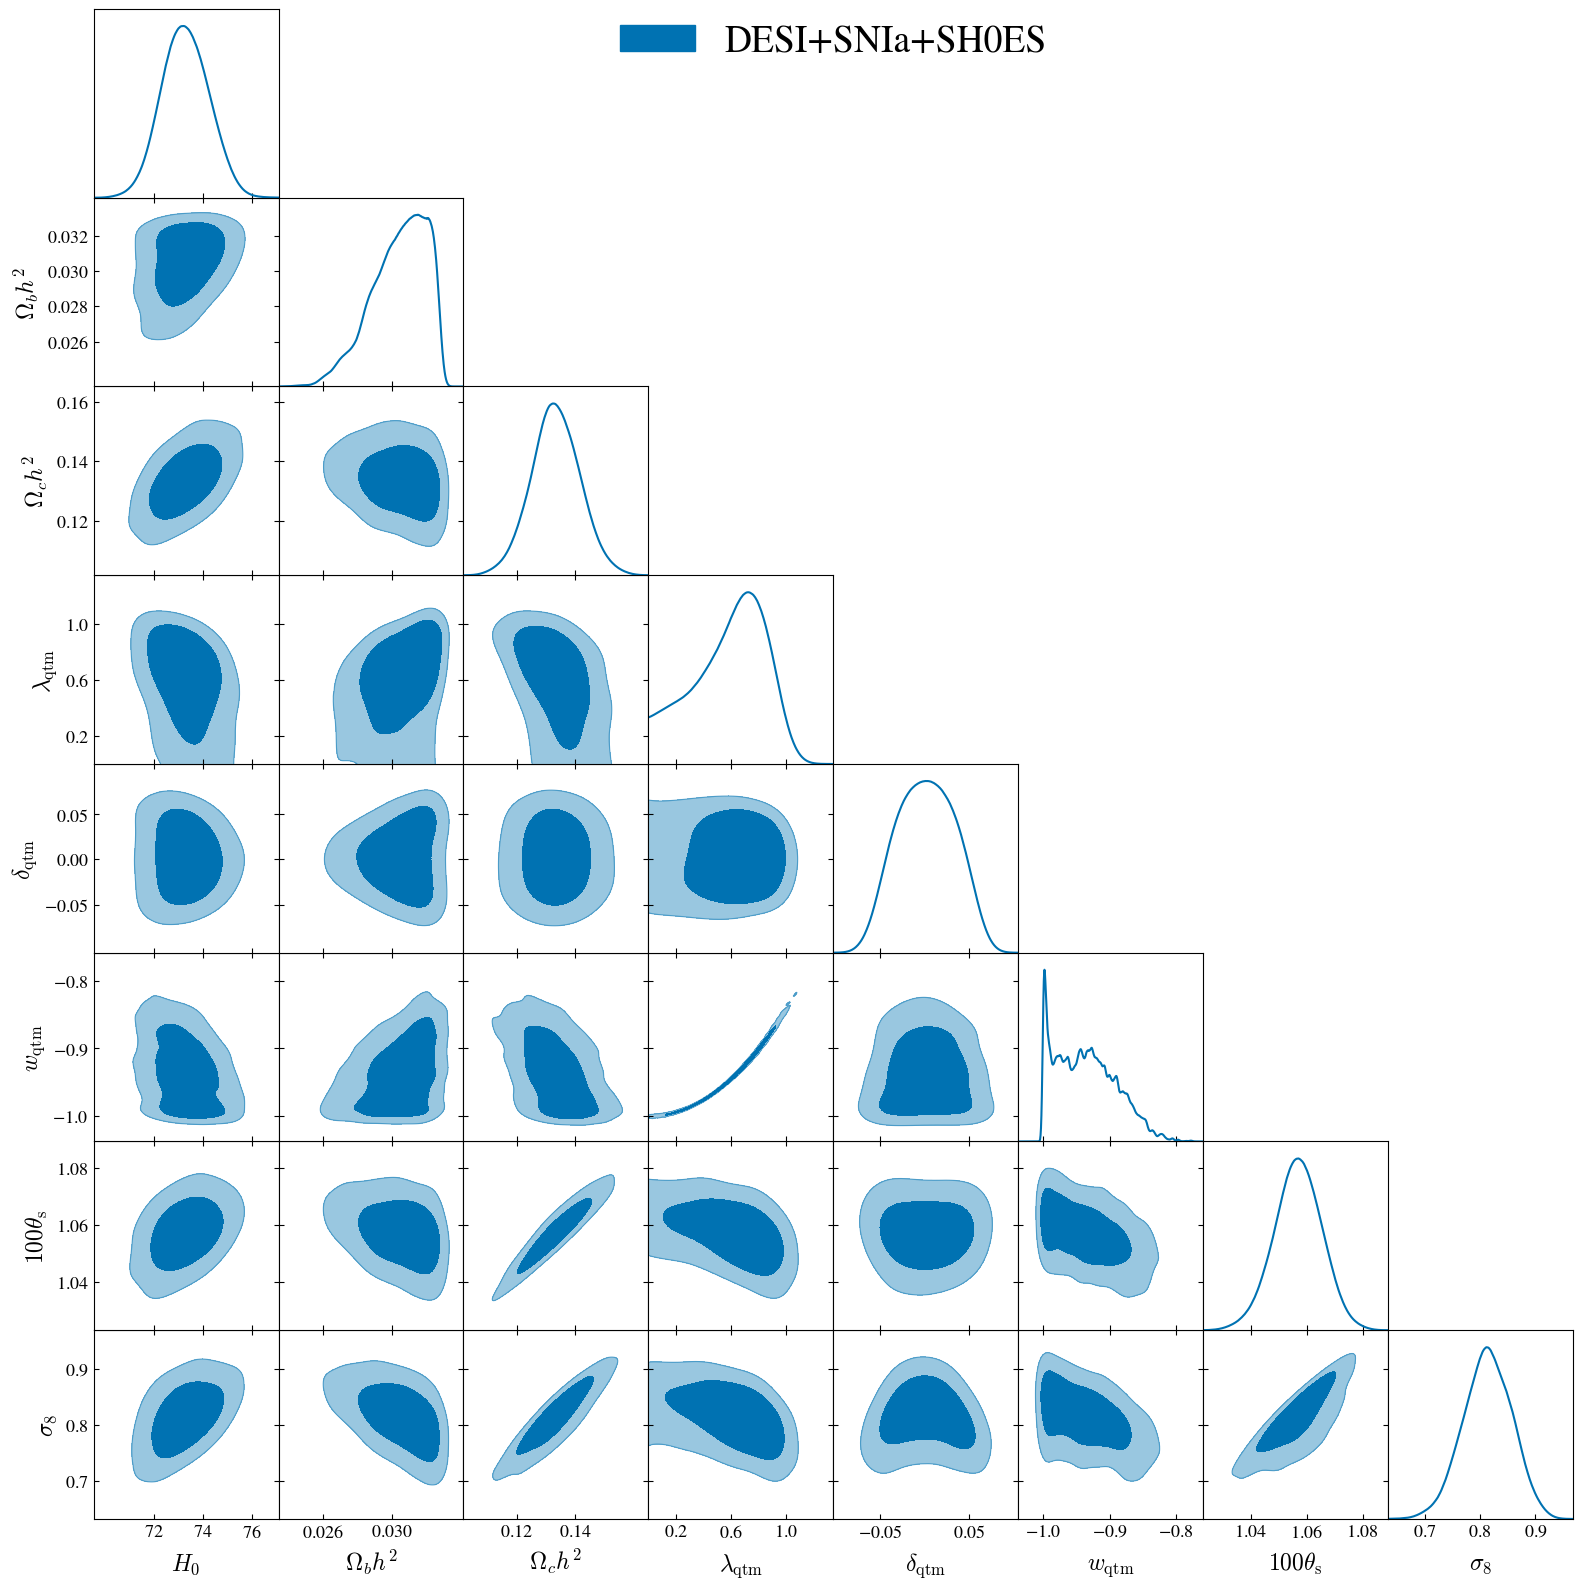

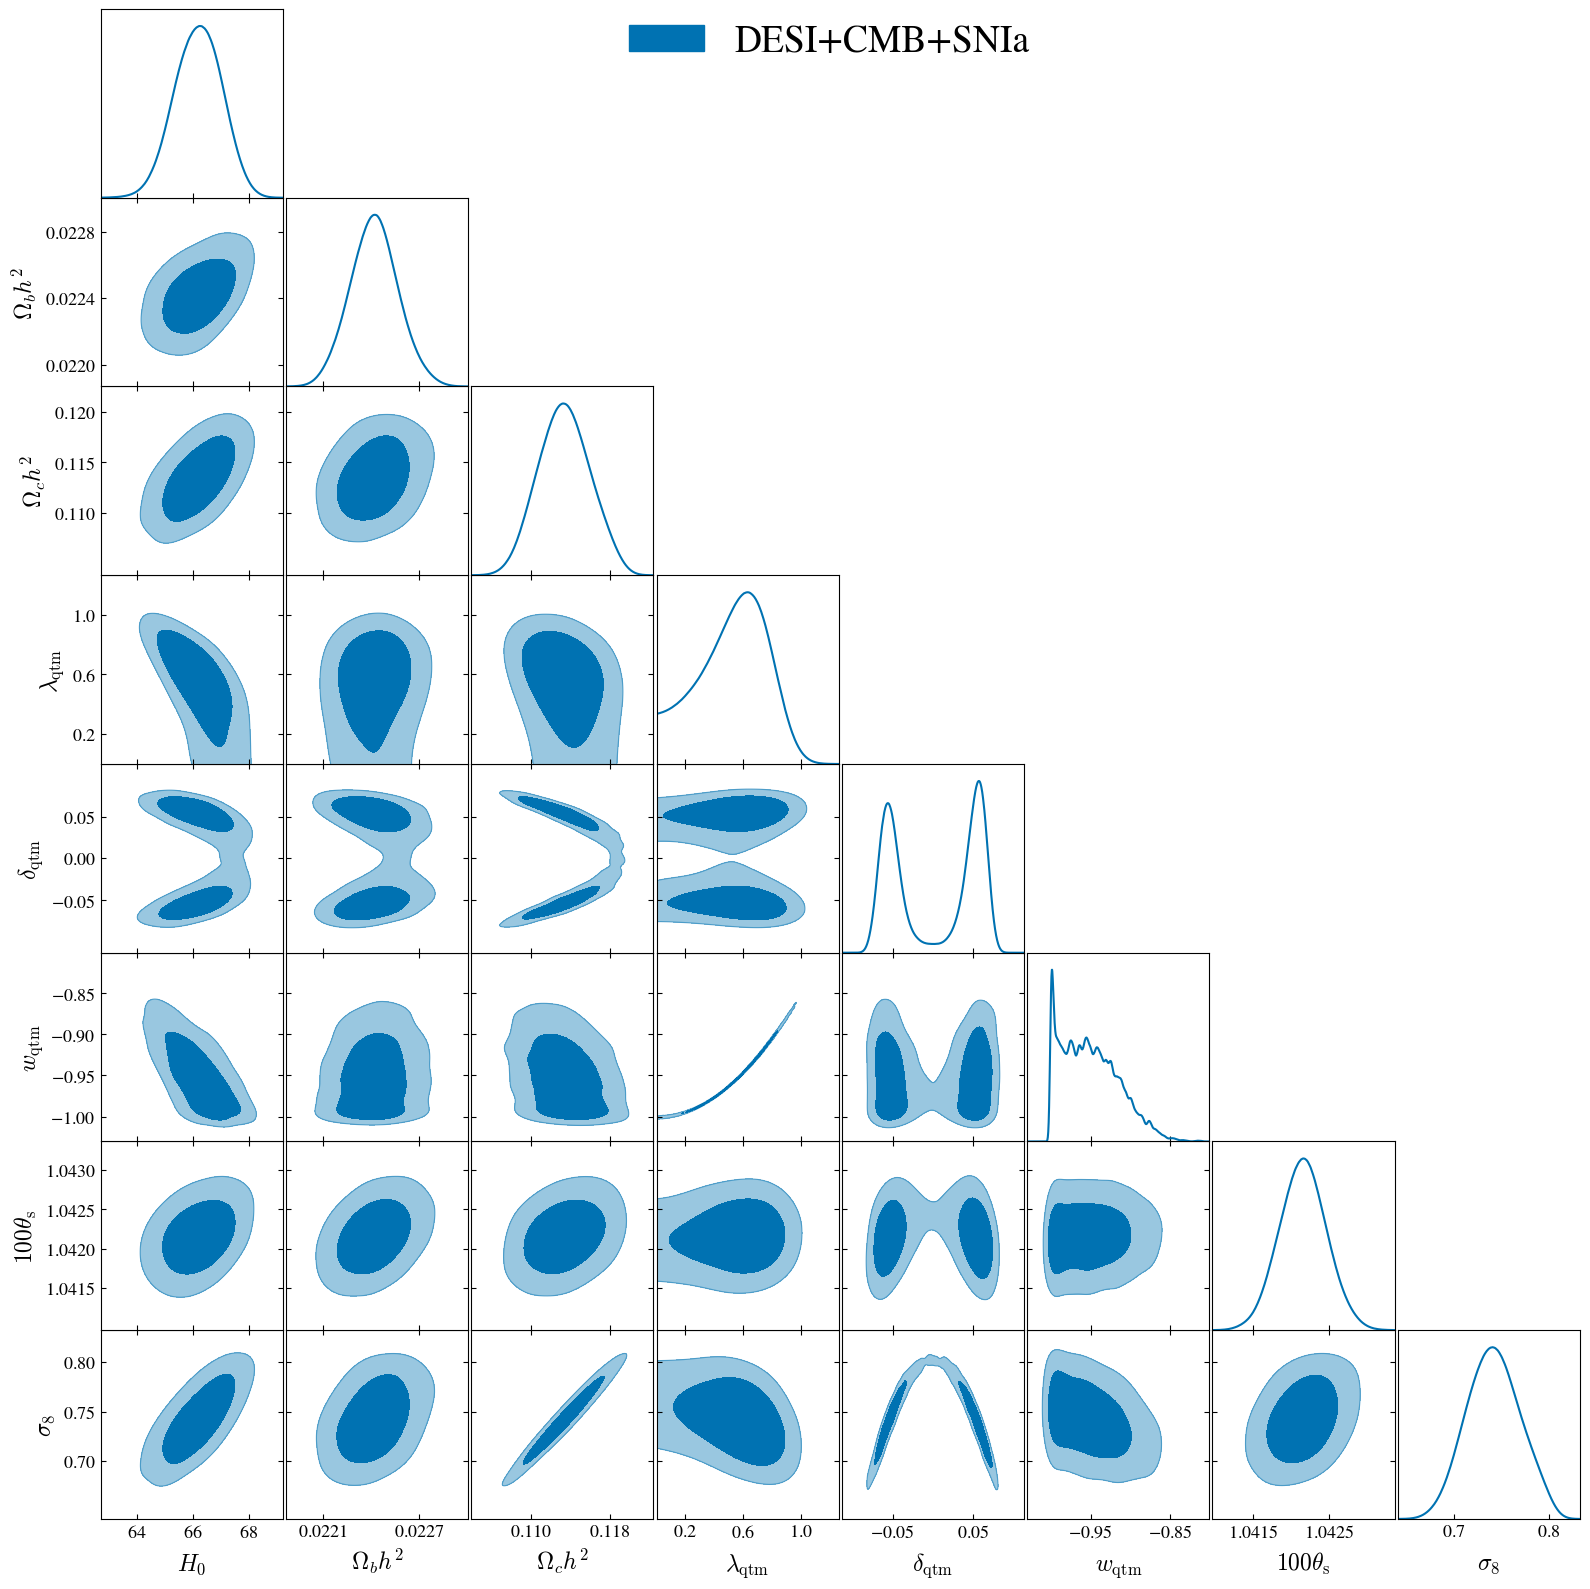

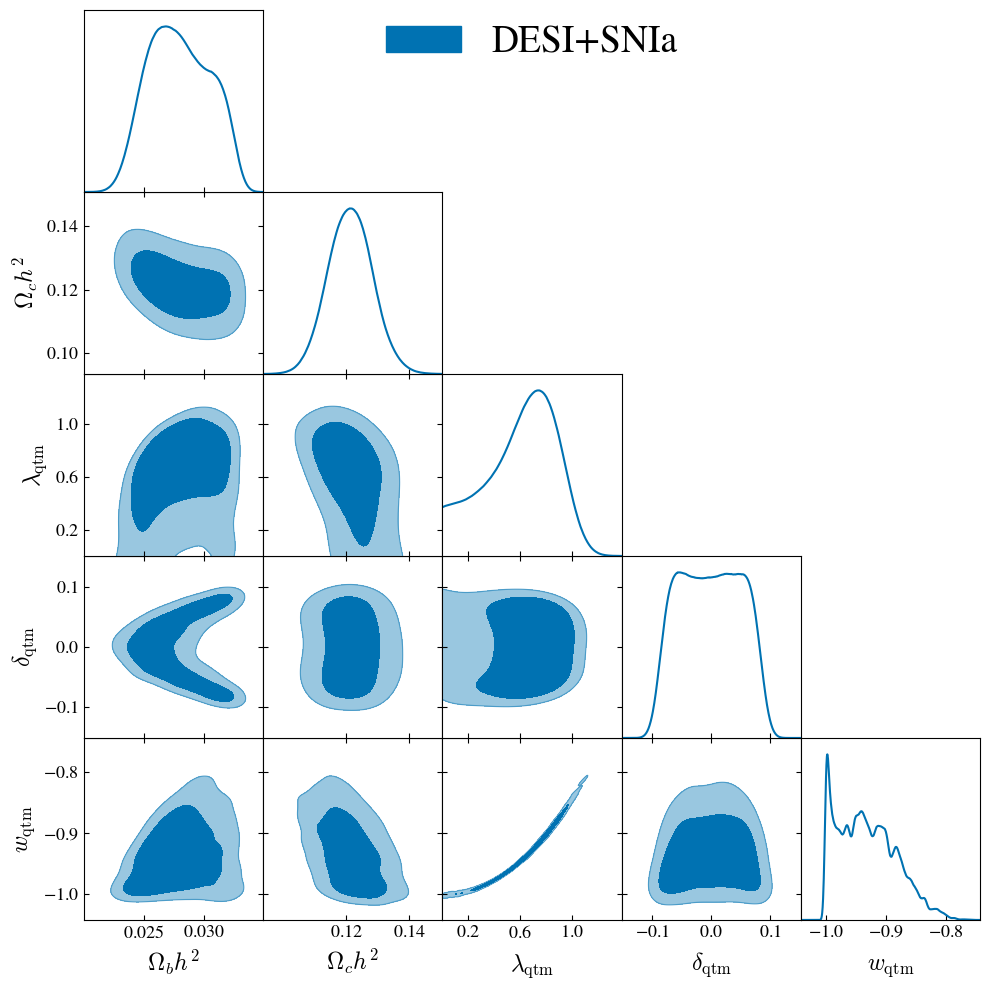

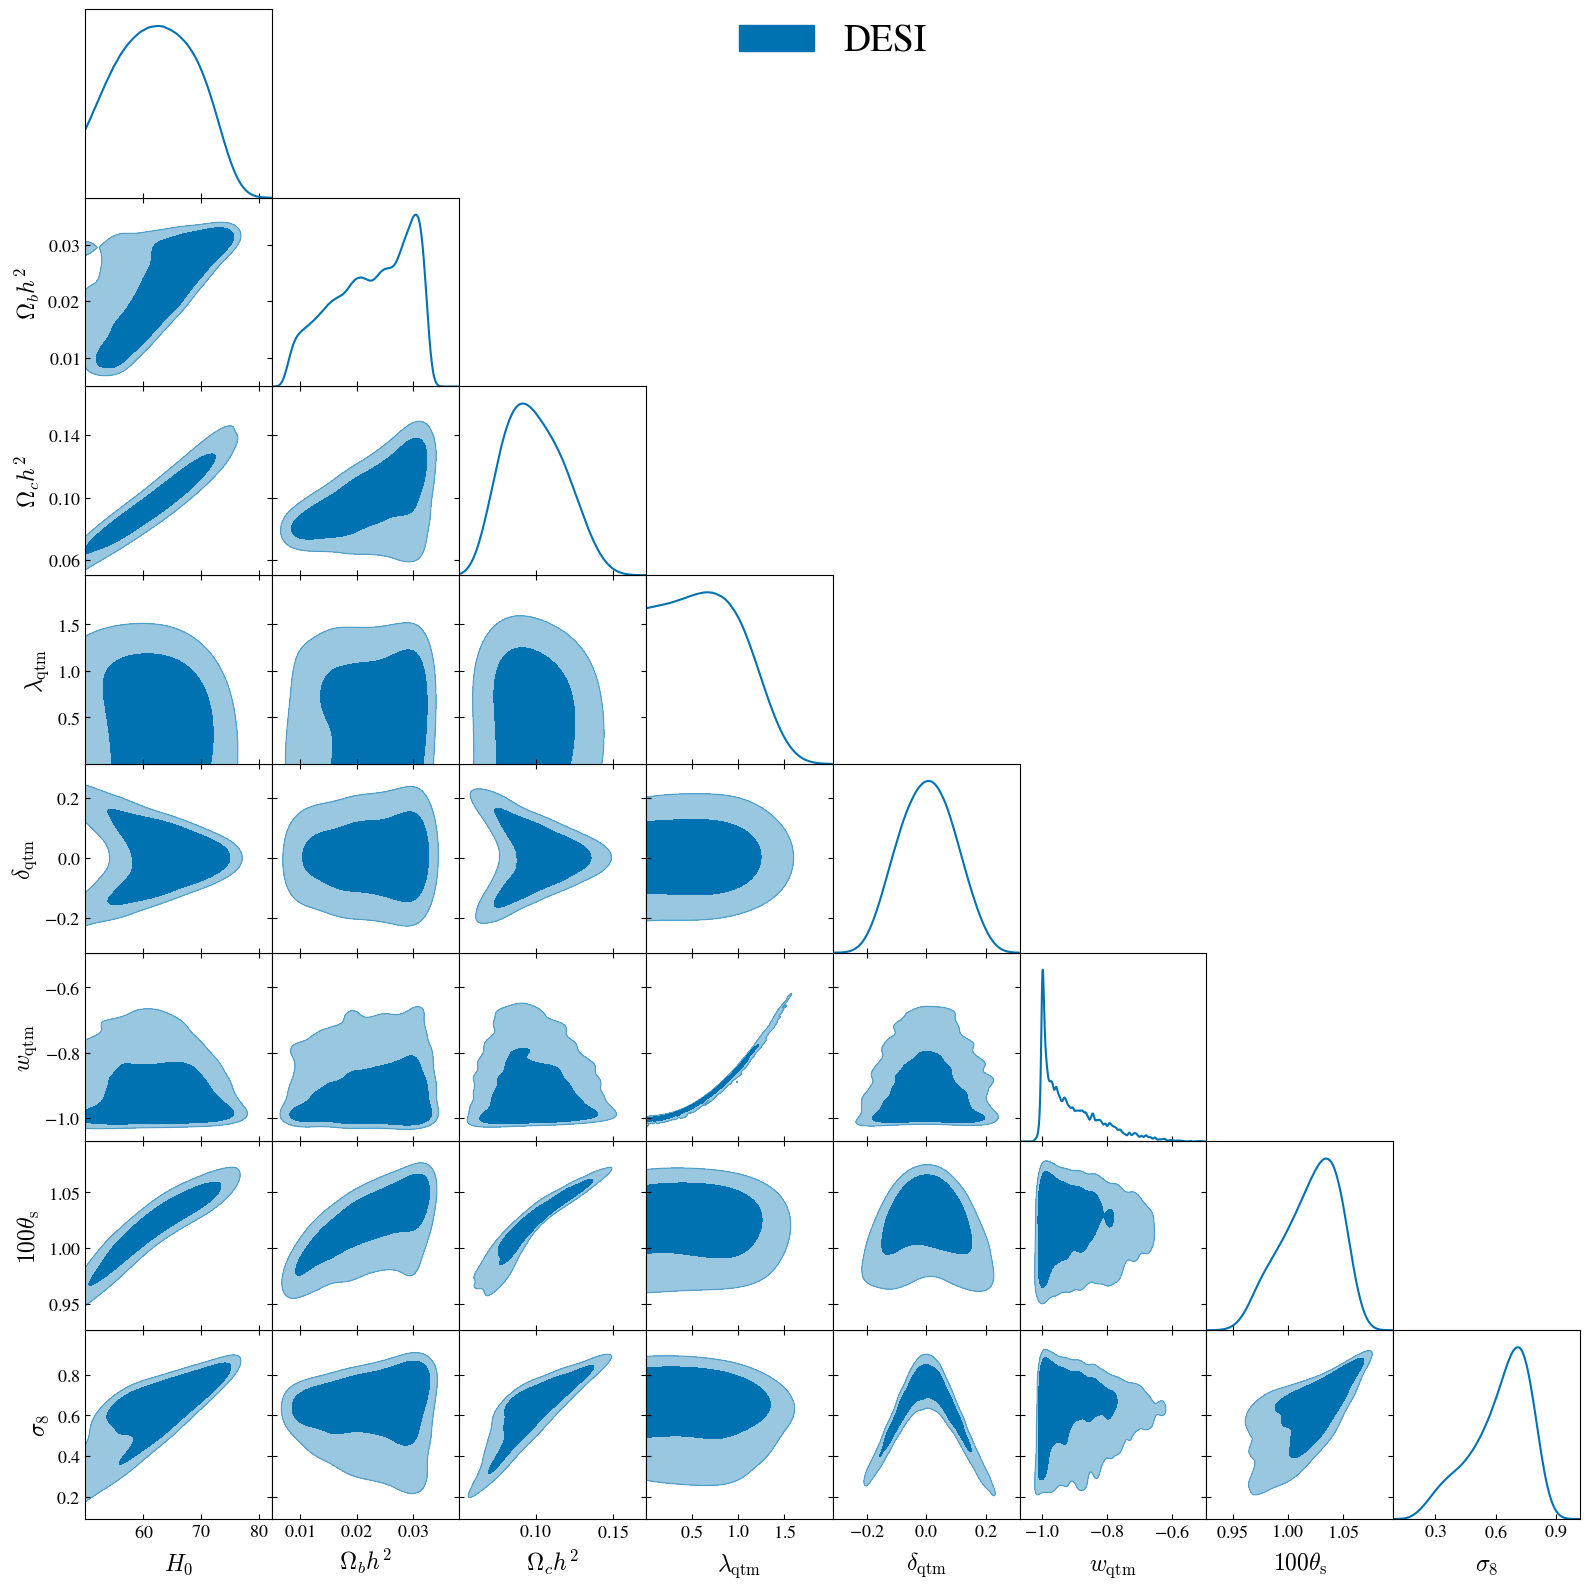

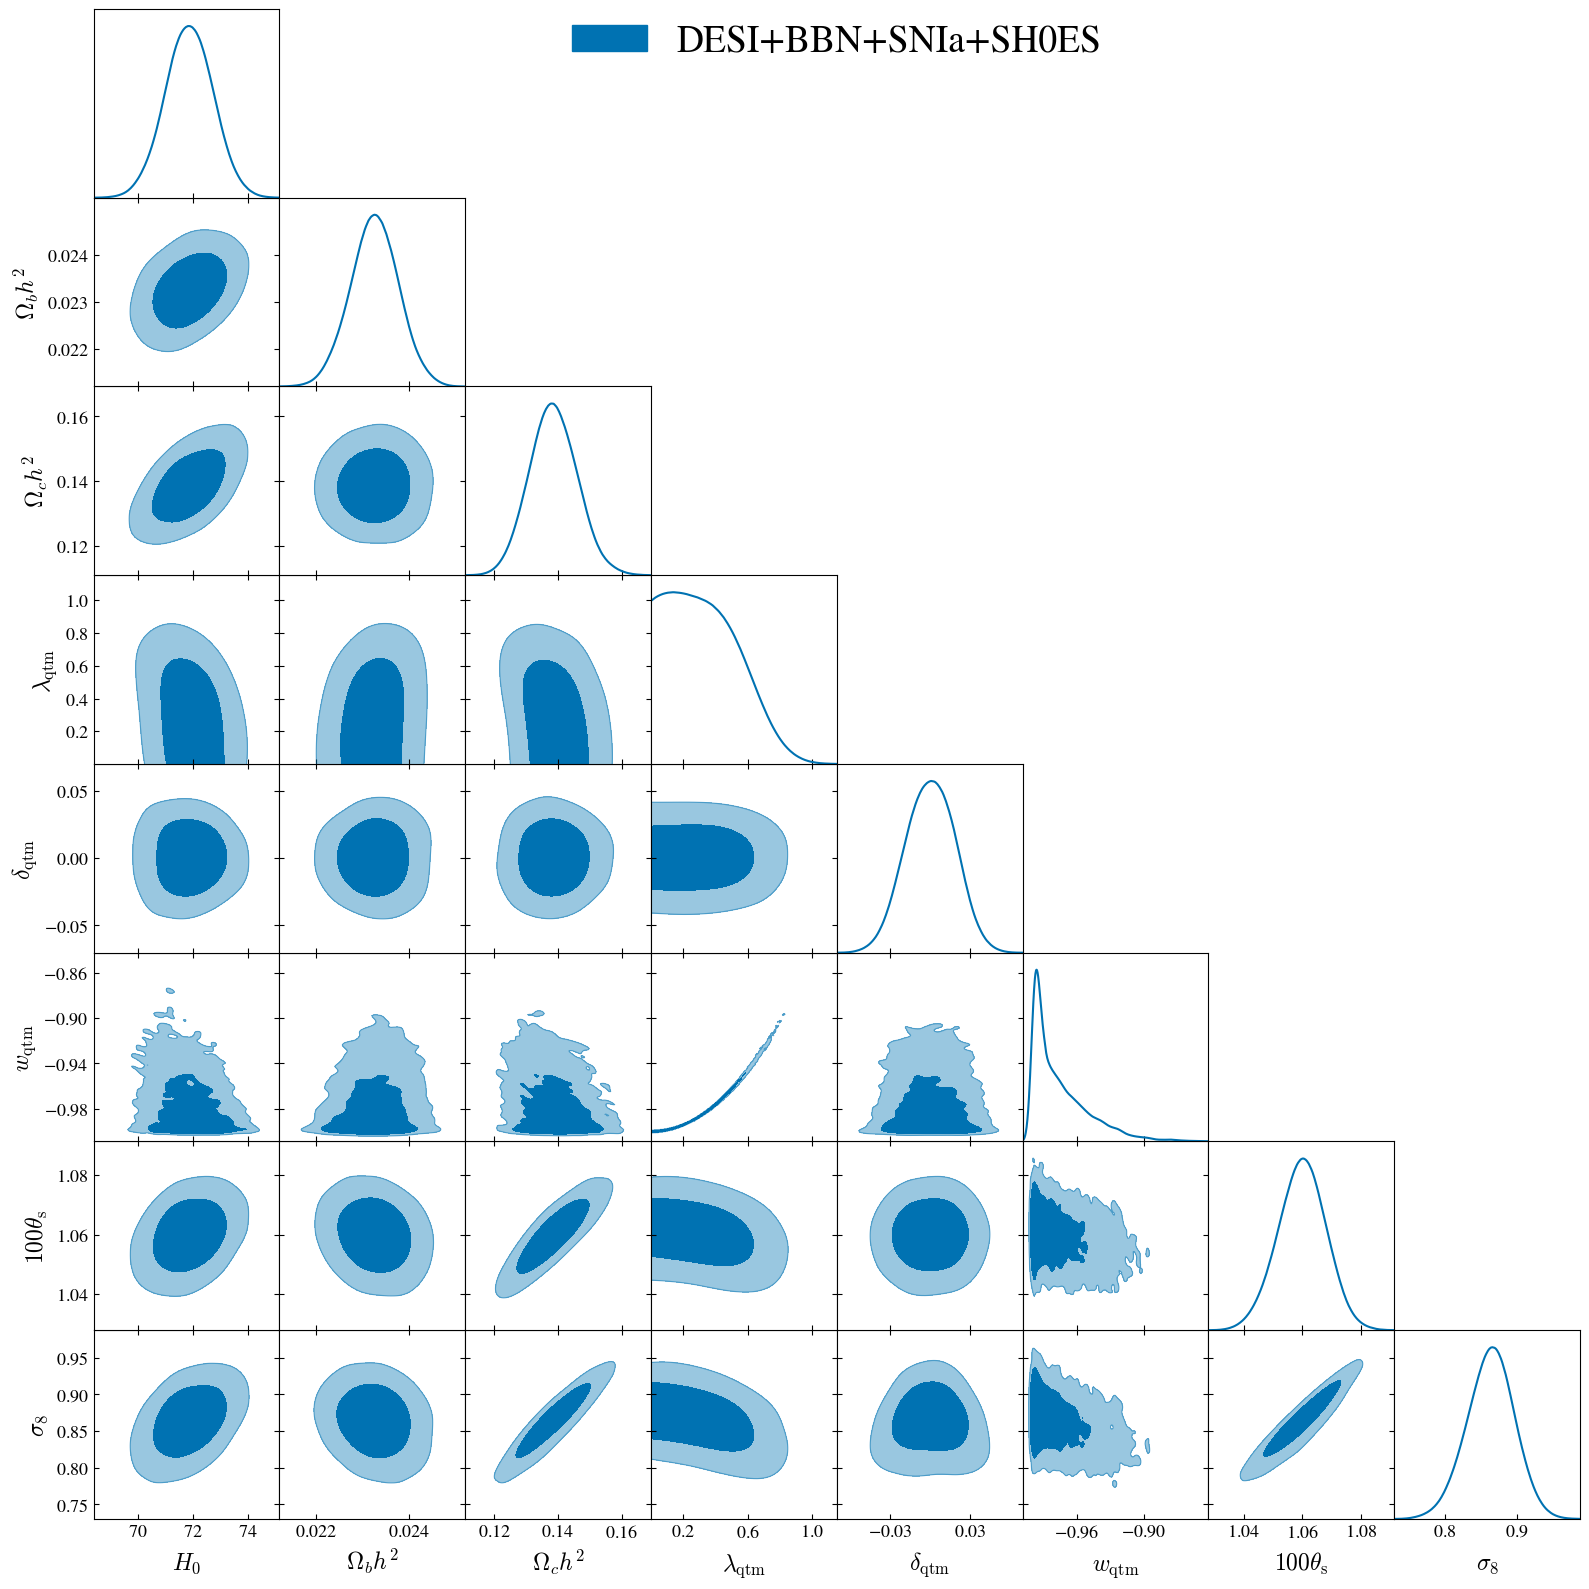

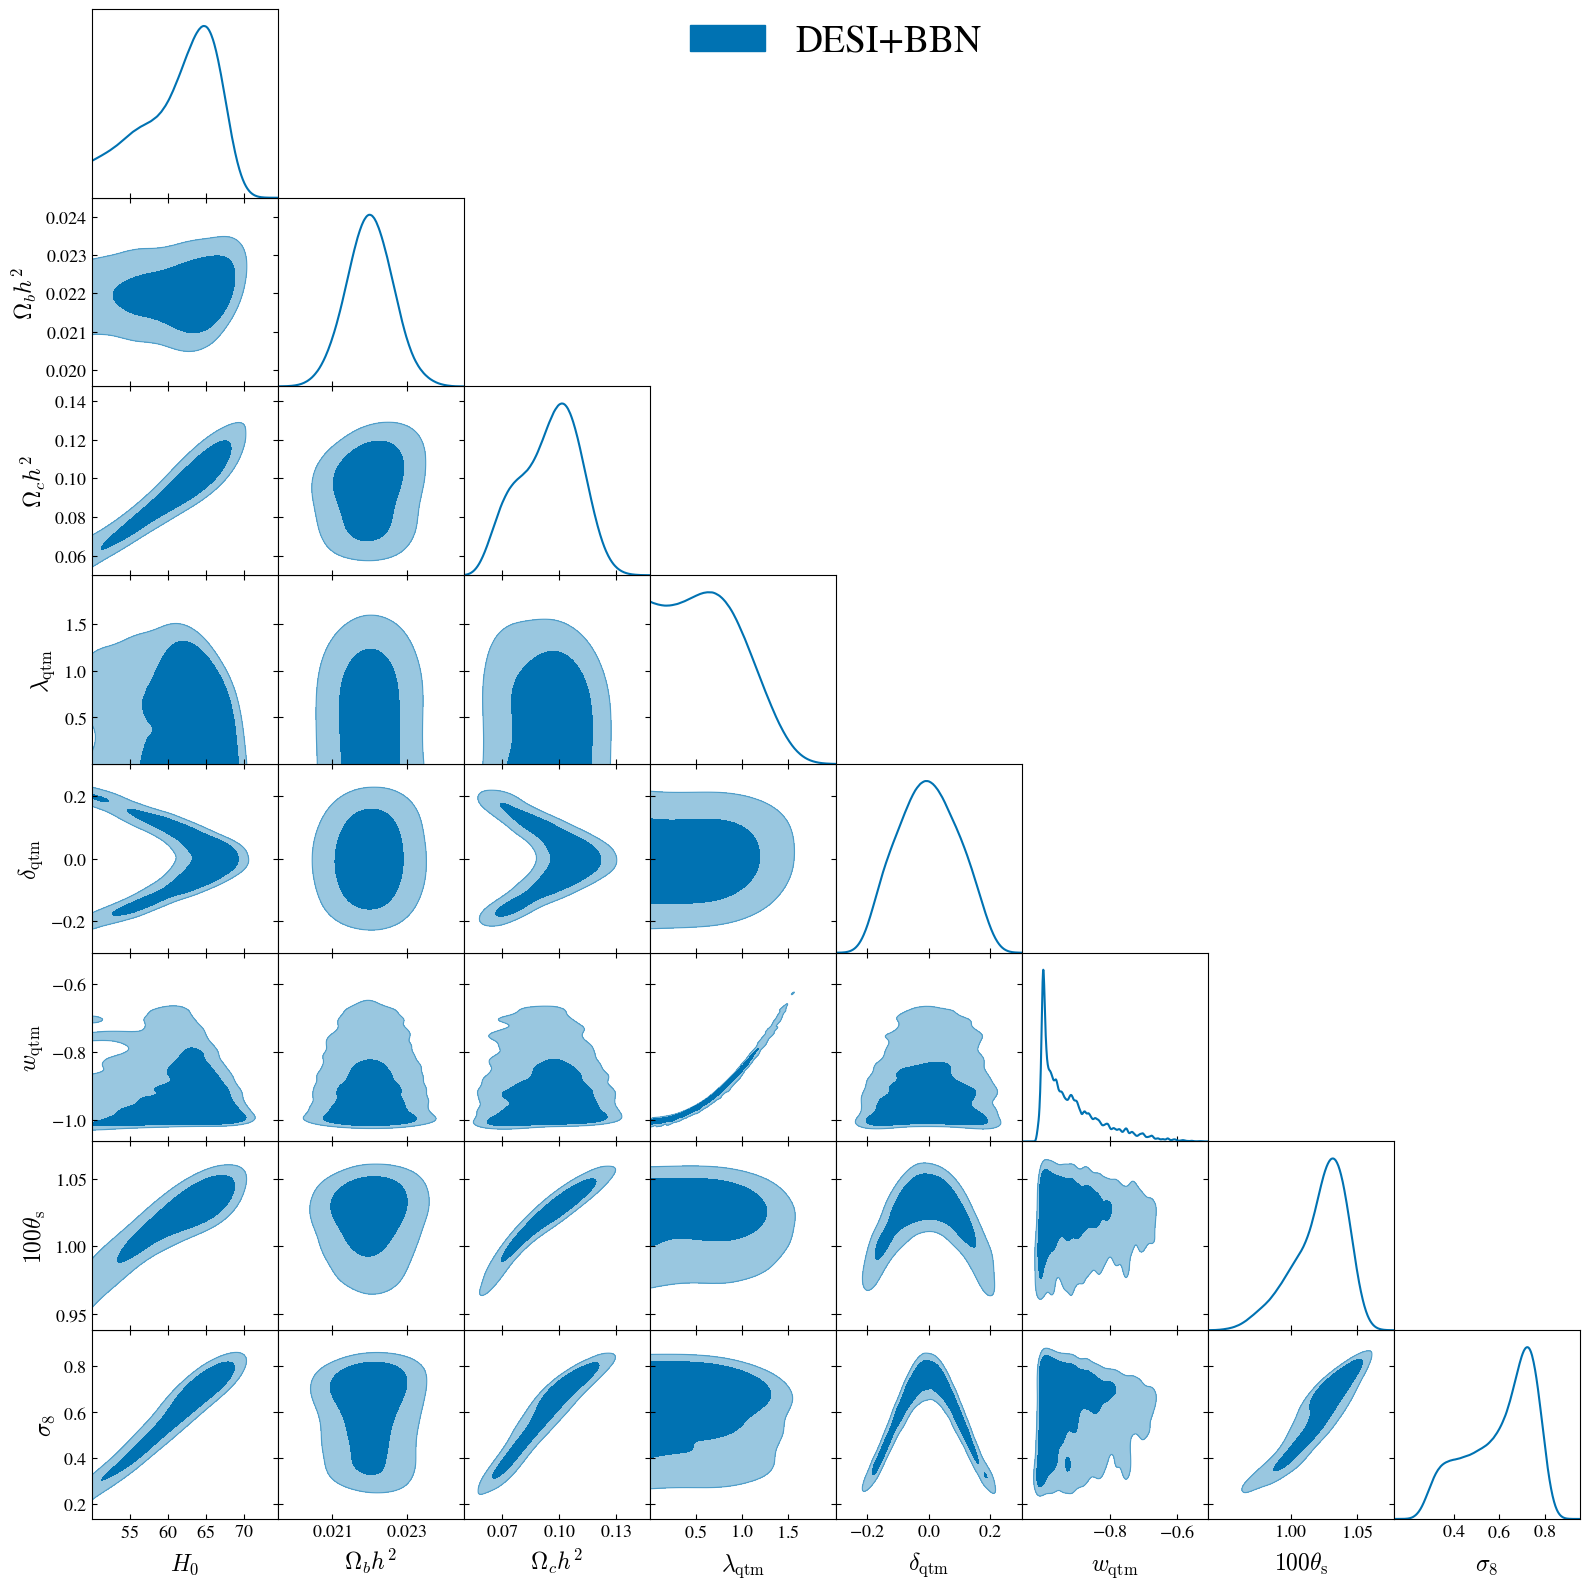

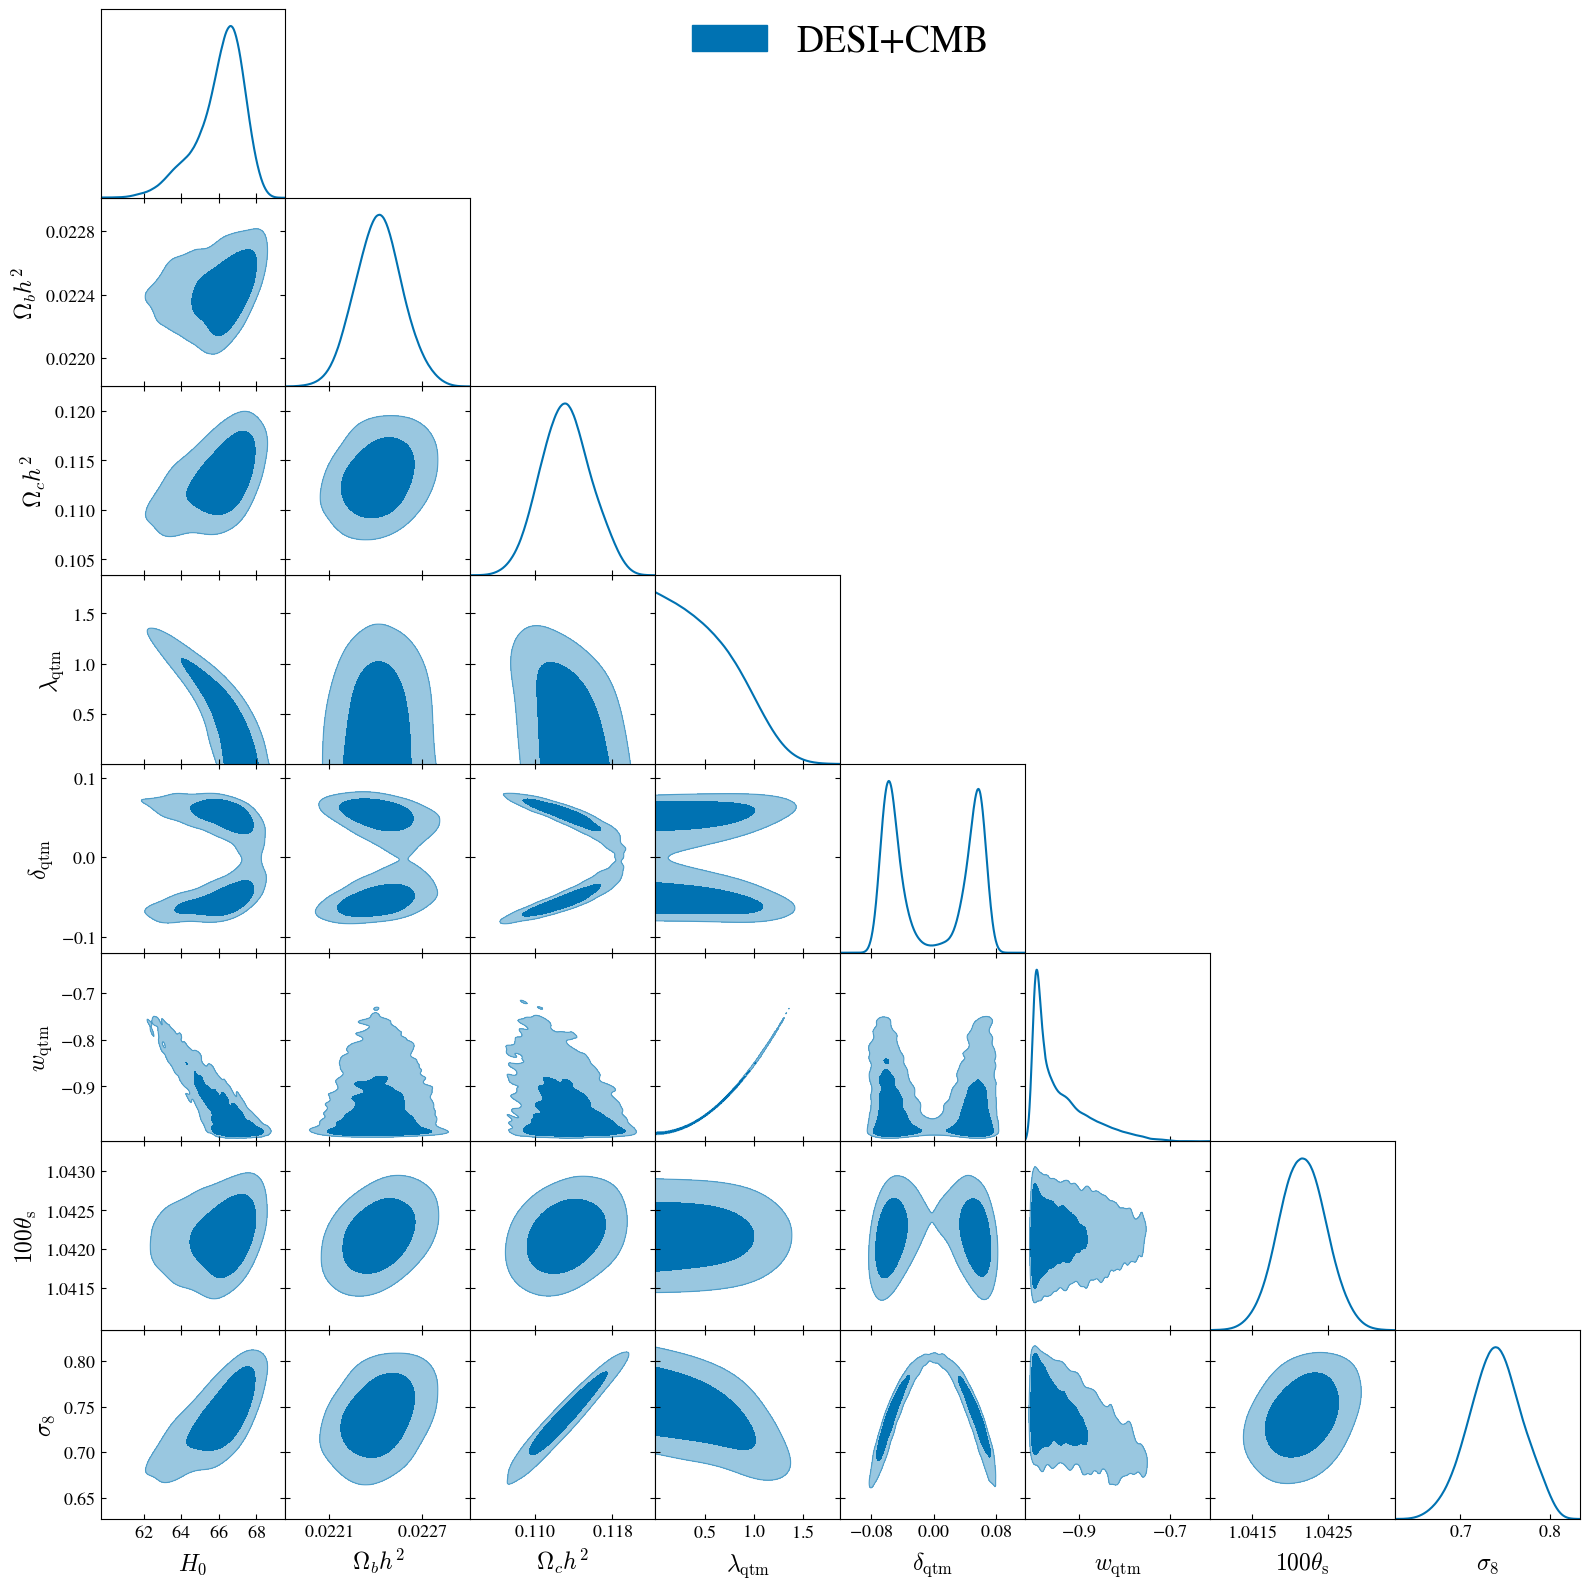

In [30]:
quintom_analyzer.plot_triangle(params=['H0', 'omega_b', 'omega_cdm', 'lambda_qtm', 'delta_qtm', 'w_qtm', 'theta_s_100', 'sigma8'],
                               colors=["#0072B2"],
                               fontsize=[16,20,30],
                               combined=False,
                               save_as='final')

### Overall

In [19]:
all_results = CobayaAnalyzer(chain_dicts=chains, burn_in=0.3)

Loading chains


Adding a new derived parameter, $|\delta_{\rm qtm}|$, since $\delta_{\rm qtm}$ is even symmetry, returning the exact same result whether the input value is positive or negative

In [20]:
for _, [sample, _, _] in all_results.chains.items():
    p = sample.getParams()
    try:
        abs_delta_qtm = np.abs(p.delta_qtm)
        sample.addDerived(abs_delta_qtm, name='abs_delta_qtm', label=r'|\delta_{\mathrm{qtm}}|')
    except AttributeError:
        print(f"Parameter 'delta_qtm' not found in sample: {sample.getName()}")
        continue

Parameter 'delta_qtm' not found in sample: lcdm_CMB
Parameter 'delta_qtm' not found in sample: lcdm_DESI
Parameter 'delta_qtm' not found in sample: lcdm_DESI+BBN+theta
Parameter 'delta_qtm' not found in sample: lcdm_DESI+BBN
Parameter 'delta_qtm' not found in sample: lcdm_DESI+CMB


In [21]:
all_results.generate_summary_table(params=['H0', 'Omega_m', 'lambda_qtm', 'abs_delta_qtm'], limit=1)

\begin{table*}
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{lcccc}
\toprule
Model/Dataset & H_0 & \Omega_{\rm m} & \lambda_{\rm qtm} & |\delta_{\mathrm{qtm}}| \\
\midrule
\Lambda {\rm CDM} &  &  &  & \\ 
CMB & $ 66.89\pm 0.61$ & $ 0.3232\pm 0.0087$ & ---  & ---  \\ 
DESI & $ 69^{+8}_{-4}$ & $ 0.295^{+0.013}_{-0.016}$ & ---  & ---  \\ 
DESI+BBN+$\theta_*$ & $ 68.60^{+0.60}_{-0.69}$ & $ 0.2936\pm 0.0075$ & ---  & ---  \\ 
DESI+BBN & $ 68.70\pm 0.80$ & $ 0.295\pm 0.015$ & ---  & ---  \\ 
DESI+CMB & $ 68.04\pm 0.41$ & $ 0.3071\pm 0.0054$ & ---  & ---  \\ 
\hline
Quintom &  &  &  & \\ 
DESI+BBN+SNIa & $ 61.4^{+6.6}_{-3.3}$ & $ 0.311^{+0.014}_{-0.018}$ & $ 0.58^{+0.34}_{-0.22}$ & $ 0.090^{+0.035}_{-0.083}$ \\ 
DESI+CMB+SNIa+SH0ES & $ 68.49^{+0.46}_{-0.40}$ & $ 0.2983\pm 0.0049$ & $< 0.274$ & $ 0.0170^{+0.0060}_{-0.016}$ \\ 
DESI+SNIa+SH0ES & $ 73.27\pm 0.97$ & $ 0.306\pm 0.012$ & $ 0.59^{+0.33}_{-0.19}$ & $ 0.028^{+0.011}_{-0.025}$ \\ 
DESI+CMB+SNIa & $ 66.19\pm 0.84$ & $ 0.3116^{+0

In [22]:
all_results.generate_best_fit_table(params=['H0', 'Omega_m', 'lambda_qtm', 'abs_delta_qtm'])

\begin{table*}
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{lcccc}
\toprule
Model/Dataset & H_0 & \Omega_{\rm m} & \lambda_{\rm qtm} & |\delta_{\mathrm{qtm}}| \\
\midrule
\Lambda {\rm CDM} &  &  &  & \\ 
CMB & $66.834$ & $0.324$ & ---  & ---  \\ 
DESI & $67.533$ & $0.294$ & ---  & ---  \\ 
DESI+BBN+$\theta_*$ & $68.651$ & $0.293$ & ---  & ---  \\ 
DESI+BBN & $68.565$ & $0.293$ & ---  & ---  \\ 
DESI+CMB & $68.043$ & $0.307$ & ---  & ---  \\ 
\hline
Quintom &  &  &  & \\ 
DESI+BBN+SNIa & $65.407$ & $0.297$ & $0.779$ & $0.023$ \\ 
DESI+CMB+SNIa+SH0ES & $68.736$ & $0.298$ & $0.053$ & $0.000$ \\ 
DESI+SNIa+SH0ES & $73.602$ & $0.299$ & $0.826$ & $0.003$ \\ 
DESI+CMB+SNIa & $65.843$ & $0.313$ & $0.665$ & $0.057$ \\ 
DESI+SNIa & $70.000$ & $0.297$ & $0.807$ & $0.001$ \\ 
DESI & $73.345$ & $0.302$ & $0.785$ & $0.007$ \\ 
DESI+BBN+SNIa+SH0ES & $71.962$ & $0.315$ & $0.186$ & $0.003$ \\ 
DESI+BBN & $66.074$ & $0.296$ & $0.728$ & $0.008$ \\ 
DESI+CMB & $66.995$ & $0.304$ & $0.020$ & $0.05